# Exploratory Data Analysis (EDA)


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style='whitegrid')

# Load the dataset
df = pd.read_csv('../data/attendance_dataset_cleaned.csv')
df.head()

,Date,Day_of_Week,Lecture_Number,Start_Time,End_Time,Subject,Faculty_ID,Semester,Branch,Section,...,Students_Present,Attendance_Percentage,Previous_Lecture_Attendance,Gap_Since_Previous_Lecture,Practical_Theory,Internal_Test_Week,Assignment_Due,Holiday_Before_After,Weather,Special_Event
0,10-04-2026,Friday,1,8.30 AM,9.15 AM,Mobile Application Development,SSP,3,MCA,A&B,...,46,22.55,16,Same Day,Theory,No,Yes,Before,Sunny,No
1,10-04-2026,Friday,2,9.15 AM,10.15 AM,Mobile Application Development,SSP,3,MCA,A&B,...,49,24.02,46,2 Days,Theory,No,Yes,Before,Sunny,No
2,10-04-2026,Friday,3,10.15 AM,11.15 AM,Data Science & Machine Learning,SP_MLK,3,MCA,A&B,...,72,35.29,16,Same Day,Theory,No,Yes,Before,Sunny,No
3,10-04-2026,Friday,4,11.15 AM,12.15 PM,Principles of Cloud Management and Security,KSD_SDM,3,MCA,A&B,...,66,32.35,12,1 Day,Theory,No,Yes,Before,Sunny,No
4,10-04-2026,Friday,5,1.30 PM,3.30 PM,Software Testing and Quality Assurance,DPY_AAB,3,MCA,A&B,...,48,23.53,14,3 Days,Practical,No,Yes,Before,Sunny,No


## 1. Target Distribution (Histogram)


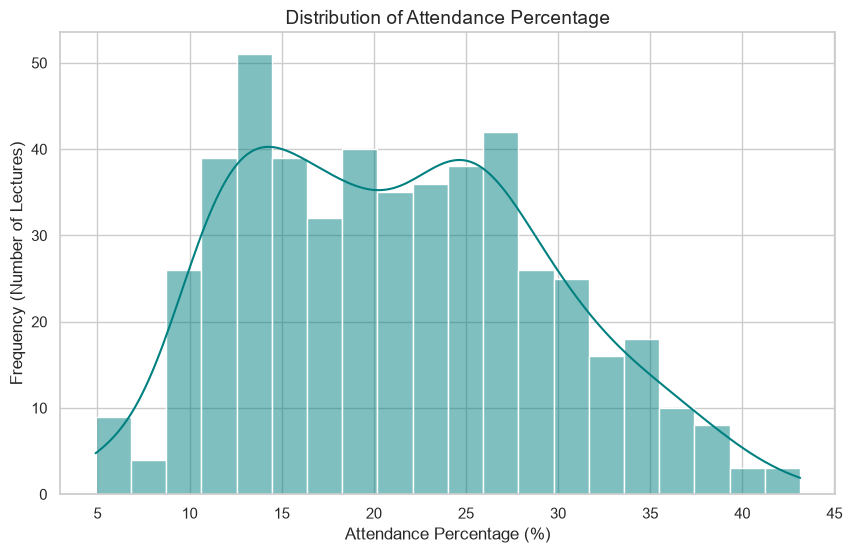

In [2]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Attendance_Percentage'], bins=20, kde=True, color='teal')
plt.title('Distribution of Attendance Percentage', fontsize=14)
plt.xlabel('Attendance Percentage (%)')
plt.ylabel('Frequency (Number of Lectures)')
plt.show()

## 2. Attendance Percentage by Subject


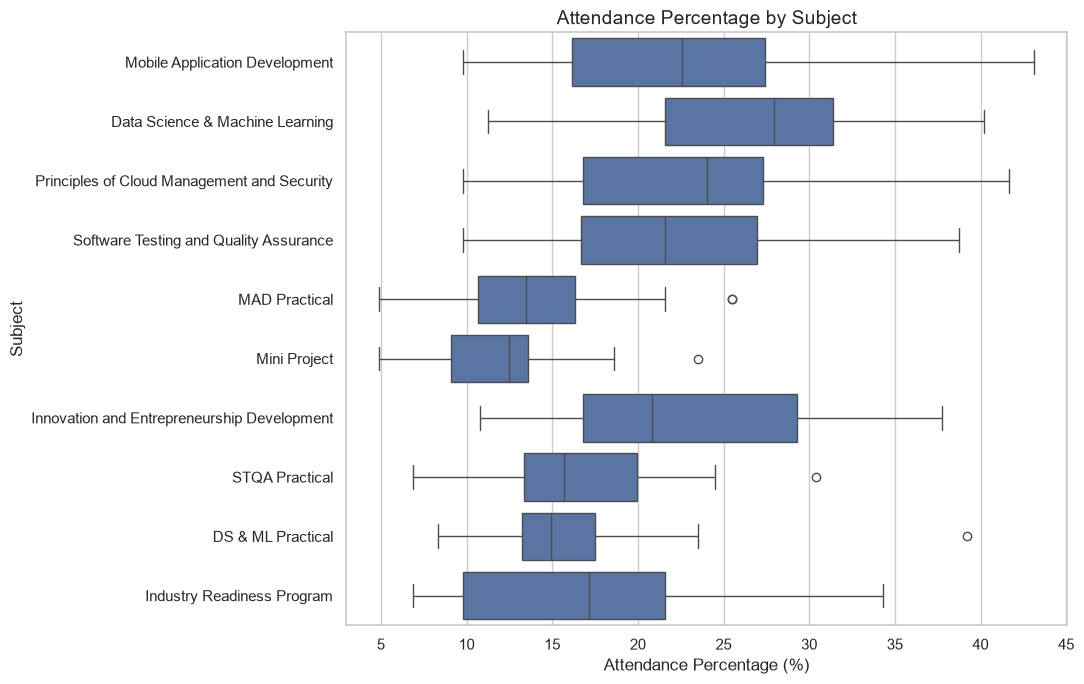

In [9]:
top_subjects = df['Subject'].value_counts().head(15).index

subject_df = df[df['Subject'].isin(top_subjects)]

plt.figure(figsize=(11, 7))
sns.boxplot(
    data=subject_df,
    y='Subject',
    x='Attendance_Percentage'
)
plt.title('Attendance Percentage by Subject', fontsize=14)
plt.xlabel('Attendance Percentage (%)')
plt.ylabel('Subject')
plt.tight_layout()
plt.show()

## 3. Correlation Heatmap
**Goal:** To prove which numerical features actually impact attendance before we train the model.
*(Note: We extract Week_Number and Day_Number_of_Semester exactly as we do in the training pipeline to see how time correlates with attendance)*

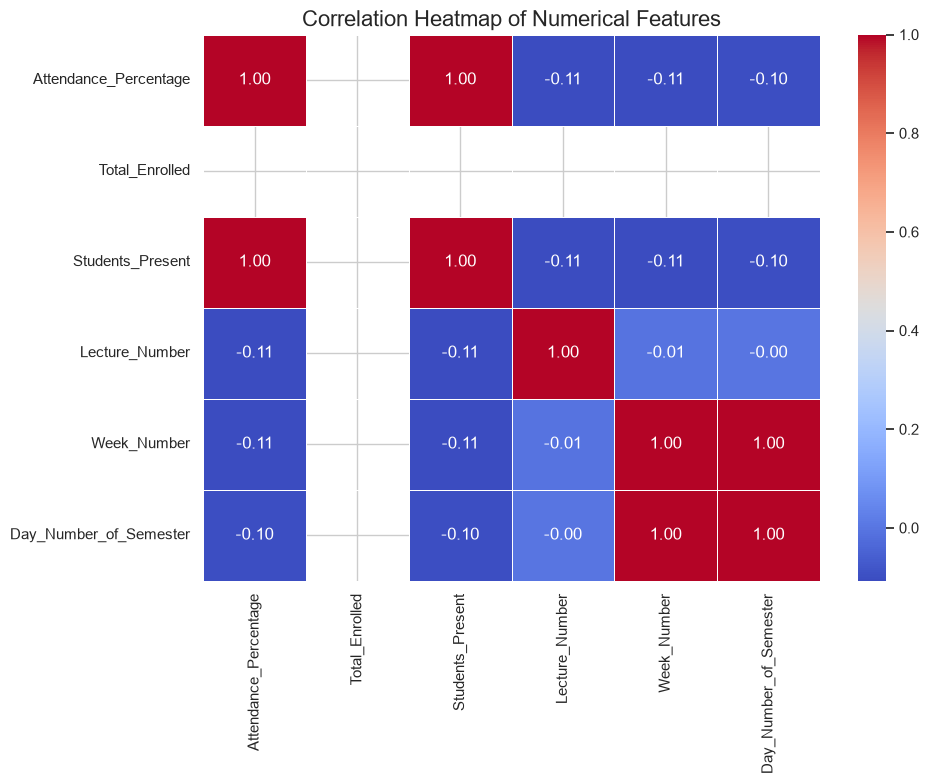

In [4]:
# Parse Date to extract Week_Number and Day_Number_of_Semester
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
start_date = pd.to_datetime('10-04-2026', format='%d-%m-%Y')
df['Week_Number'] = ((df['Date'] - start_date).dt.days // 7) + 1
df['Day_Number_of_Semester'] = (df['Date'] - start_date).dt.days + 1

# Isolate numeric columns for correlation
numeric_cols = ['Attendance_Percentage', 'Total_Enrolled', 'Students_Present', 
                'Lecture_Number', 'Week_Number', 'Day_Number_of_Semester']
numeric_df = df[numeric_cols]

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.tight_layout()
plt.show()

## 4. Attendance by Day of Week

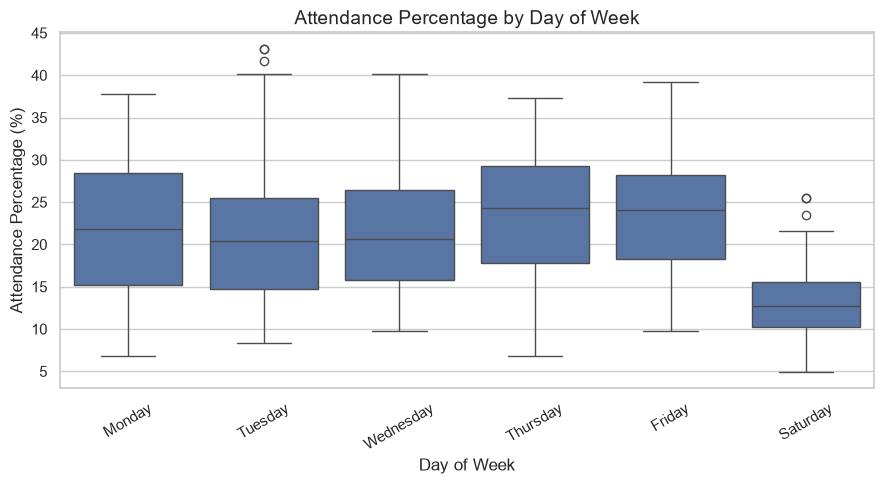

In [10]:
day_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday'
]

plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df,
    x='Day_of_Week',
    y='Attendance_Percentage',
    order=day_order
)
plt.title('Attendance Percentage by Day of Week', fontsize=14)
plt.xlabel('Day of Week')
plt.ylabel('Attendance Percentage (%)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 5. Attendance by Lecture Start Hour

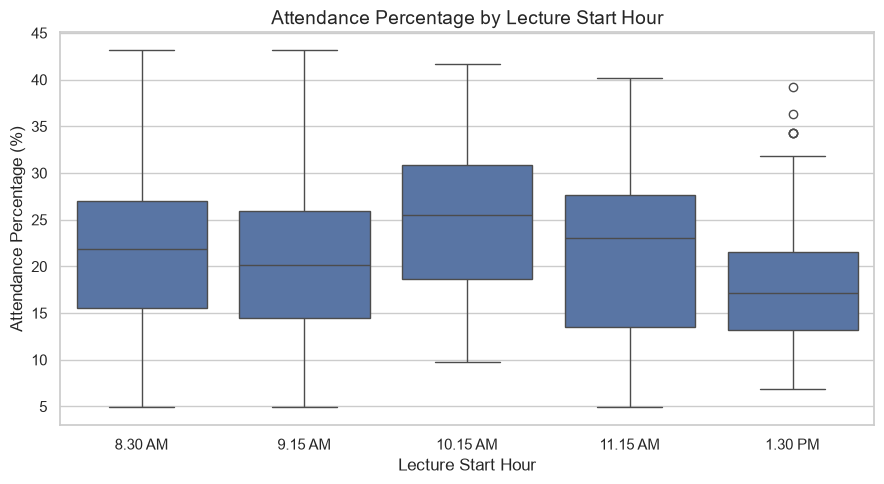

In [12]:
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df,
    x='Start_Time',
    y='Attendance_Percentage'
)
plt.title('Attendance Percentage by Lecture Start Hour', fontsize=14)
plt.xlabel('Lecture Start Hour')
plt.ylabel('Attendance Percentage (%)')
plt.xticks(sorted(df['Start_Time'].unique()))
plt.tight_layout()
plt.show()